# EXTRACCIÓN

## Librerias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
rutas = '/content/datos_tratados.csv'

In [4]:
df = pd.read_csv(rutas)
df.head(2)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.4


In [5]:
df.shape

(7043, 22)

Verifica valores NaNs y vacíos

In [6]:
for column in df.columns:
    # 1. Detectar NaN (Nulos reales)
    nulos = df[column].isnull().sum()
    # 2. Contar vacíos 
    vacios = 0
    if df[column].dtype == 'object':
        # Usamos strip() para contar también celdas con solo espacios ' ' como vacías
        vacios = (df[column].astype(str).str.strip() == '').sum()
        
    if nulos > 0 or vacios > 0:
        print(f'{column}: {nulos} NaNs, {vacios} strings vacíos/blancos')

Muestra valores únicos de las columnas 'object'

In [7]:

for col in df.select_dtypes(include='object').columns:  
    print('-'*40)
    print(f'Columna: {col} (Tiene {df[col].nunique()} valores únicos)')# Muestra el nombre y cuántos valores únicos tiene
    if df[col].nunique() < 20:
        print(df[col].unique())
    else:
        print("Demasiados valores únicos para mostrar (posiblemente nombres o IDs).")

----------------------------------------
Columna: CustomerID (Tiene 7043 valores únicos)
Demasiados valores únicos para mostrar (posiblemente nombres o IDs).
----------------------------------------
Columna: Churn (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: Gender (Tiene 2 valores únicos)
['Female' 'Male']
----------------------------------------
Columna: SeniorCitizen (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: Partner (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: Dependents (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: PhoneService (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: MultipleLines (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: InternetService (Tiene 3 valores únicos)
['DSL' 'Fiber optic' 'No']
------------------------------

Información de columnas y dataset

In [8]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# Pre procesamiento

Remover columnas irrelevantes:

In [10]:
# Eliminamos el id, no necesitamos para esta parte (muchos valores)
df = df.drop(columns=['CustomerID'])

In [11]:
df.tail(3)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65
7042,No,Male,No,Yes,Yes,63,No,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Electronic check,1.97,59.00,3707.60


In [12]:
# Multicolieridad
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [13]:
# Verificamos valores nulos:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# EDA

Correlación entre variables númericas

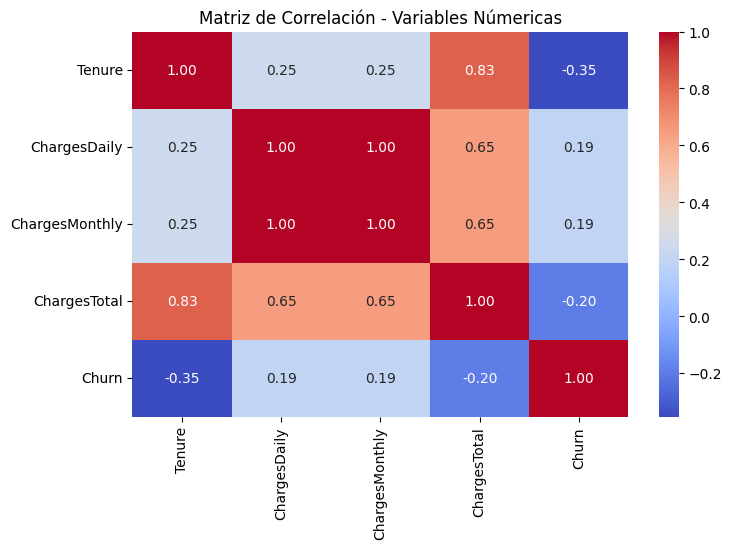

In [14]:
# Para hacer uso de la matriz correlacion se debe utilizar valores de tipo númericos
df_numeric = df.select_dtypes(include=['int64', "float64"])
df_numeric['Churn'] = df['Churn'].map({"Yes":1, "No":0})

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Variables Númericas")
plt.show()

Se presenta autocorrelación, ver variables ChargesDaily y ChargesMontly son la misma variables.Es redundate, se opta por dejar la variable ChargesMontly.


Otra situación que se visualiza entre las variables Tenure y ChargesTotal, nos quedamos con variable Tenure


Eliminacion de variables ChargesDaily y ChargesTotal

In [15]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

Anáĺisis de Churn por categoría (Variables categóricas)

Seleccionar variables categóricas

In [16]:
# Creamos df temporal para ver las variables categóricas que tienen similitud con Churn
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Churn')

Tabla de proporción por categoria

In [17]:
for col in categorical_cols:
    print(f"\n Análisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index")*100)


 Análisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 Análisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 Análisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 Análisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 Análisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Anterior manera, toma tiempo y si fuesen 50 variables?

Se sugiere utilizar el método del Chi-cuadrado ( $\chi^2$ )

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [19]:
# Se crea copia df
df_rank = df.copy()

df_rank['Churn'] = df_rank['Churn'].map({"Yes":1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar x e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar test Chi-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Crear DataFrame con ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores, # valor de similitud
    "p_value": p_values # valor de confianza(%)
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [20]:
significant_vars = chi_df[chi_df["p_value"] < 0.05]


print("\n Variables significativas (p < 0.05): ")
display(significant_vars)


 Variables significativas (p < 0.05): 


,Variable,Chi2 Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Se observa en el dataframe temporal que las variables Gender y PhoneService se puede eliminar

In [21]:
df = df.drop(columns =["Gender","PhoneService"])

# Split

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y, # desbalanceo
    random_state=42
)

 ONE-HOT ENCODING

In [25]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first= True)

# Garantizar que treno y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [26]:
X_train.head(3)

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False


Verificar desbalanceamiento:

In [27]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


# Entrenamiento

Modelo 1 - Regresión Logistica:

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [29]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresión Logística")
print(classification_report(y_test, y_pred_log_normal))

Regresión Logística
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



recall de yes da 0.52 no es bueno

¿Que hay aproximadamente 65 personas de 100 que se van, que estamos viendo que son la pre la precisión, verdad?
@2 1 hora 14 minutos 18 segundos
Solo que de ese 65% yo creo que solamente perdón de esas 65% de 65% yo creo que solamente el 50% realmente yo sé que se van el otros 48 no estoy seguro
@2 1 hora 14 minutos 37 segundos
Entonces, prácticamente me está diciendo que de esas 65 personas.
@2 1 hora 14 minutos 46 segundos
podría decirte que 20 solamente está haciendo un vuelca un buen cálculo Por decirlo de alguna forma porque estamos tácticamente quitando la mitad 50 por cientos verdad de esa predicción que nos está diciendo rical Entonces si nos ponemos a hacer ese calvo vemos que es muy bajo estamos teniendo un número

Modelo 2 - Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



Un acurracy a partir del 75% se considera bueno,igual el acurracy no es del todo

random forest esta peor q regresion logistica

Ahora con balanceamiento

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



¿Y por esto qué hacemos?
@1 1 hora 22 minutos 36 segundos
que seas mode después que hacemos la separación de Trenoritage y vemos si nuestra variable está realmente resolución. Ahora ven acá, nuestra acoración se disminuyó, todo bien, está 74% en relación a antes que era 80, se quedó un poco mejor, se disminuyó
@1 1 hora 22 minutos 57 segundos
Se exposiento, pero fija.
@1 1 hora 23 minutos
Ahora te hago, yo te doy una precisión de 50% de los clientes que yo predí que van a journal.

Una aseguranza de casi 80% O sea, de los clientes que van a chornar, yo consigo prever 50% de los clientes que van a chornar. Lo recaudo aquí está buenísimo. Claro, esto, la regresión logística no es el mejor modelo para churn.

# Evaluación

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

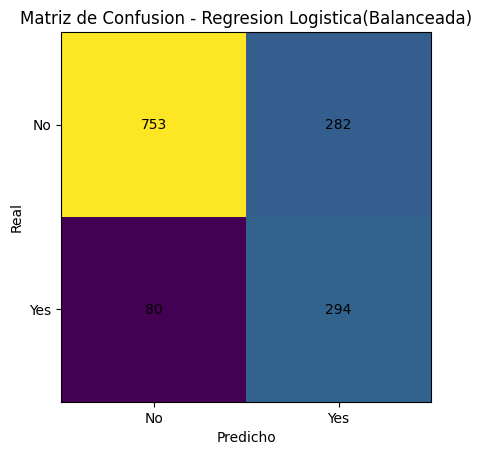

In [35]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion Logistica(Balanceada)")
plt.xlabel('Predicho')
plt.ylabel('Real')

# Colocar números dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

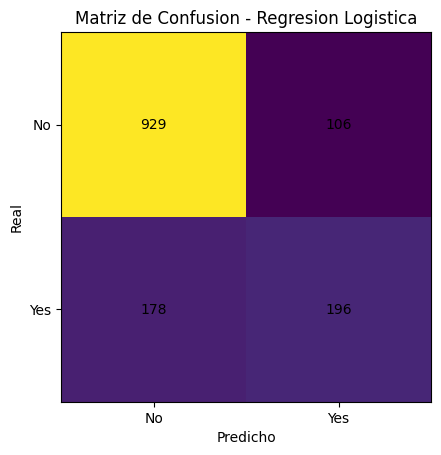

In [37]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion Logistica")
plt.xlabel('Predicho')
plt.ylabel('Real')

# Colocar números dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()


Orador 1
1 hora 28 minutos 24 segundos1:28:24
@1 1 hora 28 minutos 24 segundos
Esto.
@1 1 hora 28 minutos 38 segundos
178% fue los que.
@1 1 hora 28 minutos 42 segundos
El modelo.
@1 1 hora 28 minutos 46 segundos
No consiguió prevé, se dejó pasar y 196 fue lo que conseguí, lo que se consiguió prevé.
@1 1 hora 28 minutos 55 segundos
Pero no es una proporción tan diferente. Pero 178 es un número muy alto para nuestro modelo no prevé, se deja pasar.
@1 1 hora 29 minutos 7 segundos
Oh, cero mi cámara, cero.
@1 1 hora 29 minutos 12 segundos
Ahora, cuando hacemos el balsamiento, vean la diferencia.
@1 1 hora 29 minutos 19 segundos
80% ellos dejó pasar, pero 294 somos clientes que el Chuck y nuestro modelo identificó correctamente.

Exacto, yo le yo le había dicho al revés en él, pero es así. 294 es el número que el modelo al final detectó